# Figures pdf

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(Seurat)
    library(scran)
    library(scater)
    library(batchelor)
    library(SingleCellExperiment)
    library(scater)
    library(Matrix)
    library(reshape2)
    library(data.table)
    library(BiocParallel)
    library(dplyr)
    library(gridExtra)
    library(ggrastr)
    library(ggpubr)
})

    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
out_dir = paste0(main, '07_atlas_mapping/')
plot_dir = paste0(main, '07_atlas_mapping/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)

source(paste0(main, "mapping_functions.R"))
atlas_in = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/'


Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend




In [3]:
mappings = read.csv(paste0(out_dir,"mapped.csv"))

In [4]:
load_data(normalise=TRUE)
sce = sce[Matrix::rowSums(counts(sce)) > 0,]

In [4]:
meta_complete = merge(meta, mappings, by='cell')

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'merge': object 'meta' not found


In [ ]:
meta_complete$umap_1 = as.numeric(meta_complete$umap_1)
meta_complete$umap_2 = as.numeric(meta_complete$umap_2)

In [ ]:
# plot original atlas projection to make comprehensible
atlas_meta = fread(paste0(atlas_in, 'sample_metadata.txt.gz'))
atlas_meta = atlas_meta[atlas_meta$doublet==FALSE & atlas_meta$stripped==FALSE,]
atlas_umap <- atlas_meta[, c('cell', 'umapX', 'umapY')]
colnames(atlas_umap) <- c('closest.cell', 'umapX.mapped', 'umapY.mapped')
meta_complete <- merge(meta_complete, atlas_umap, by='closest.cell', all.x=TRUE)[, union(names(meta_complete), names(atlas_umap))] # last part just to keep column order
meta_complete = meta_complete[order(meta_complete$index),]

### UMAP

In [19]:
umap_theme = theme_void() + 
            theme(panel.border=element_rect(color='black', fill=NA),
            plot.title = element_text(hjust = 0.5),
            text=element_text(size=20),
            legend.position='none')

In [192]:
p1 = ggplot(meta_complete[meta_complete$tdTom=='negative',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=0.8, size=0.5) + 
    ggtitle('Wild-Type') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p2 = ggplot(meta_complete[meta_complete$tdTom=='positive',], aes(umapX.mapped, umapY.mapped, col=celltype.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=0.8, size=0.5) + 
    ggtitle('Eomes KO') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

In [193]:
p3 = ggarrange(rasterize(p1, dpi=600), rasterize(p2, dpi=600))

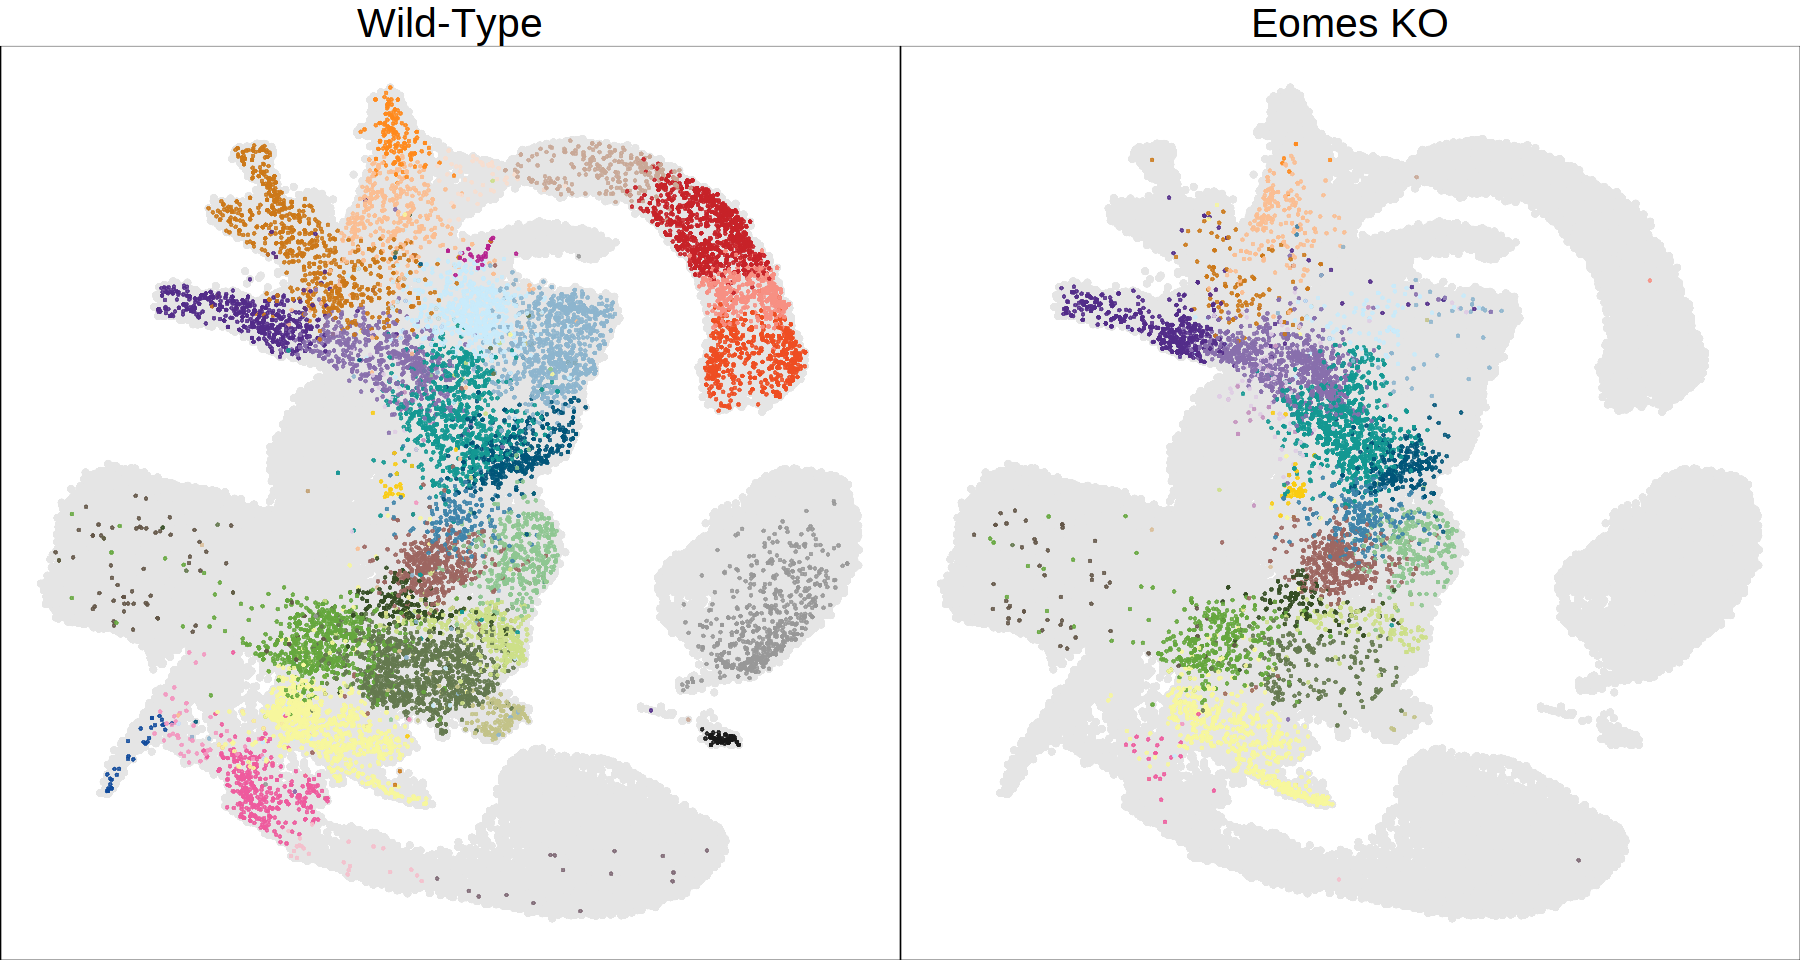

In [194]:
p3

In [195]:
pdf(file.path(main, '/figures/mapping.pdf'), width=10, height=5)
    p3
dev.off()

png 
  2

### Eomes expression

In [36]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genenames = genenames[genenames$gene %in% rownames(sce)]
genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
genenames$gene_name[genenames$gene_name==''] = NA
genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
genenames = genenames[order(match(genenames$gene, rownames(sce)))]
rownames(sce) = genenames$gene_name

In [39]:
summary(colnames(sce) == meta$cell)

   Mode    TRUE 
logical   30171 

In [60]:
meta_complete$Eomes = as.numeric(as.vector(logcounts(sce['Eomes', meta_complete$cell])))

In [66]:
p4 = ggplot(meta_complete[meta_complete$tdTom=='negative',], aes(umapX.mapped, umapY.mapped, col=Eomes)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=1, size=0.7) + 
    ggtitle('') + 
    viridis::scale_color_viridis() + 
    umap_theme

p5 = ggplot(meta_complete[meta_complete$tdTom=='positive',], aes(umapX.mapped, umapY.mapped, col=Eomes)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=1, size=0.7) + 
    ggtitle('') + 
    viridis::scale_color_viridis() + 
    umap_theme

In [67]:
p6 = ggarrange(rasterize(p4, dpi=600), rasterize(p5, dpi=600))
pdf(file.path(main, '/figures/eomes_expression.pdf'), width=10, height=5)
    p6
dev.off()

png 
  2

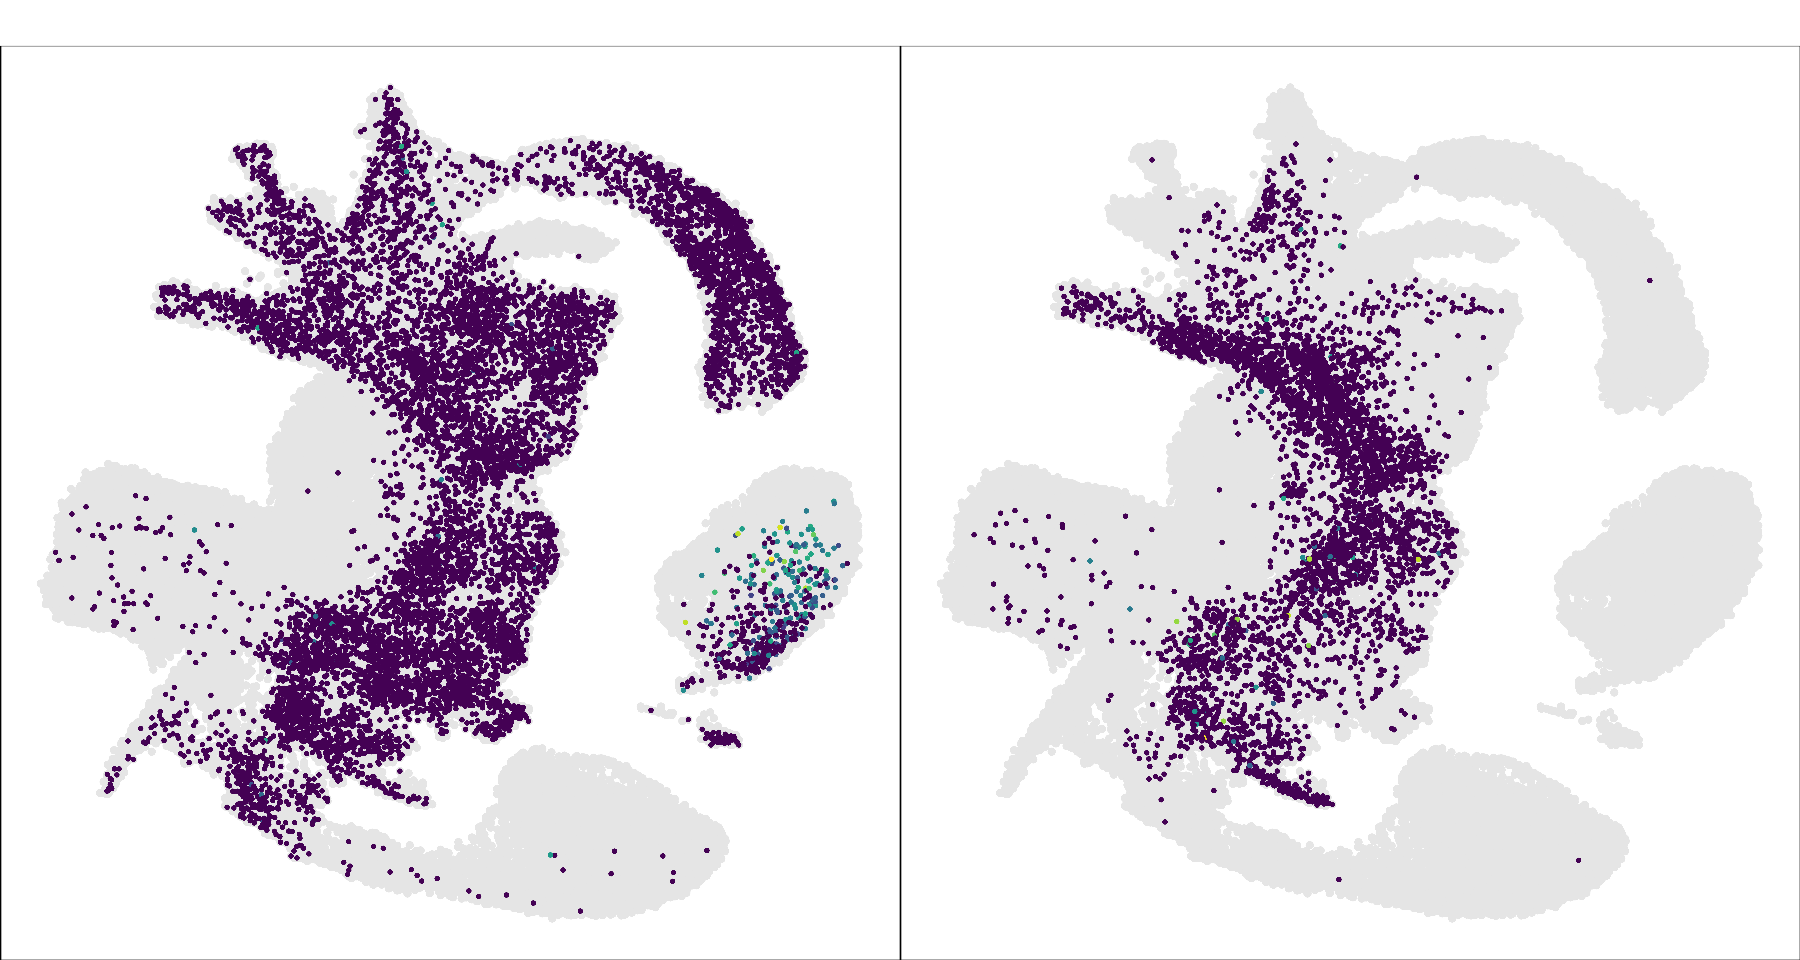

In [153]:
p6

## Differential Abundance

In [81]:
celltype_prop = as.data.table(meta_complete) %>% 
    .[,Ntot:=.N, by='Sample_name'] %>% 
    .[,proportion:=.N/Ntot, by=c('Sample_name','celltype.mapped')] %>% 
    unique(by=c('Sample_name','celltype.mapped'))

In [143]:
celltype_prop_stats = celltype_prop %>% 
    .[,`:=`(mean=mean(proportion), sd=sd(proportion)), by=c('celltype.mapped', 'tdTom')] %>% unique(by=c('celltype.mapped', 'tdTom')) %>% 
    .[,c('celltype.mapped', 'tdTom', 'mean', 'sd')]
merge = data.table(celltype.mapped = rep(unique(celltype_prop_stats$celltype.mapped), 2), tdTom=c(rep('negative', length(unique(celltype_prop_stats$celltype.mapped))), rep('positive', length(unique(celltype_prop_stats$celltype.mapped)))))
celltype_prop_stats = merge(celltype_prop_stats, merge, all.y=TRUE) %>%
    .[,celltype.mapped:=factor(celltype.mapped, levels=rev(unique(celltype.mapped)))]

In [156]:
p7 = ggplot(celltype_prop_stats, aes(celltype.mapped, mean, fill=tdTom)) + 
    geom_bar(stat='identity', position='dodge') + 
    geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.2,
                 position=position_dodge(.9)) + 
    scale_fill_manual(values=c('negative'='black', 'positive'='red')) +
    coord_flip() +  
    ylab('Proportion') + xlab('') + 
    theme_bw() + 
    theme(text=element_text(size=20, color='black'),
          axis.text=element_text(color='black'),
          legend.position='none')

In [189]:
pdf(file.path(main, '/figures/differential_abundance.pdf'), width=10, height=10)
    p7
dev.off()

Warning message:
“Removed 8 rows containing missing values (geom_bar).”


png 
  2

Warning message:
“Removed 8 rows containing missing values (geom_bar).”


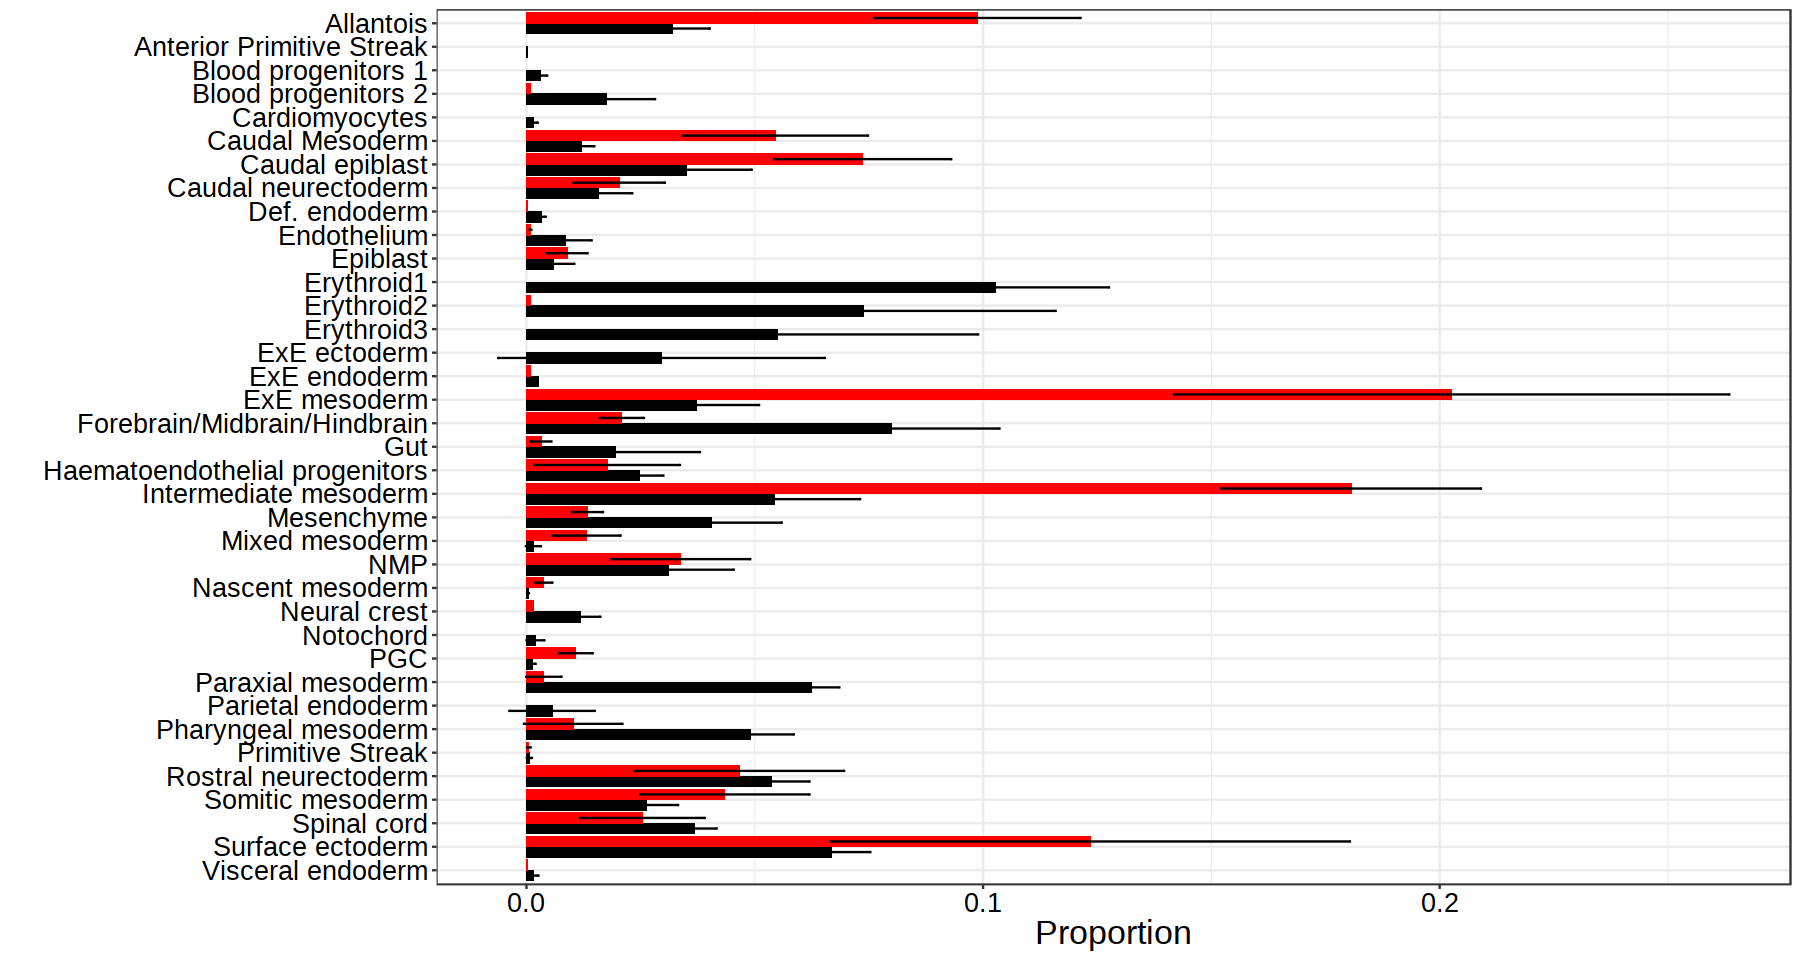

In [158]:
p7

In [166]:
# UMAP 
labels = as.data.table(meta_complete) %>% .[,`:=`(umapXmean=mean(umapX.mapped),umapYmean=mean(umapY.mapped)), by='celltype.mapped'] %>% unique(by='celltype.mapped') %>%  .[,c('celltype.mapped', 'umapX.mapped', 'umapY.mapped')]

In [186]:
p8 = ggplot(meta_complete, aes(umapX.mapped, umapY.mapped, label=celltype.mapped)) + 
    geom_point(aes(col=tdTom), size=0.5) + 
    scale_color_manual(values=c('negative'='black', 'positive'='red')) +
   # ggrepel::geom_text_repel(data = labels, aes(label=celltype.mapped), col='black', size=5) + 
    theme_void() + 
    theme(legend.position='none')

In [191]:
pdf(file.path(main, '/figures/chimera_umap_tdtom.pdf'), width=9, height=10)
    rasterize(p8, dpi=600)
dev.off()

png 
  2

Milo ran in separate notebook

### Plot DEGs

In [5]:
# These are the old DEGs, mapped against the host cells. not the ones mapped 
DEGs = fread(file.path(main, '09_gene_expression_analysis_old/old/tomato_DEGs_edgeR_filtered.csv'))

In [115]:
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=10, xlim=5, ylim=120, label_groups = NULL) {
  to.plot = DEGs[celltype == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  to.plot = to.plot[,logFC:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))]
    
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*0.9), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim)) +
    annotate("text", x=0, y=ylim*0.95, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim+1, y=ylim*0.95, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim-1, y=ylim*0.95, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i,
           paste0('n tdTom -: ', to.plot[1,groupA_N], ', n tdTom +: ',  to.plot[1,groupB_N]))
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(rasterize(p, dpi=600))
}

In [113]:
dir.create(file.path(main, '/figures/DEGs'), showWarnings = FALSE)

In [116]:
for(i in unique(DEGs$celltype)){
    p = gg_volcano_plot(i, xlim=3, top_genes=15)
    ct = gsub("/", "_", i)
    pdf(sprintf('%s/figures/DEGs/DEGs_%s.pdf', main, ct), width=8, height=8)
         print(p)
    dev.off()
}